In [11]:
# ==========================================
# IMPORTS
# ==========================================

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

print("Mixed Precision Enabled")

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (384,384)
BATCH_SIZE = 32
NUM_CLASSES = 7

Mixed Precision Enabled


In [12]:

print("TensorFlow Version :", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print(f"GPU Detected : {gpus[0].name}")
else:
    print("Running on CPU")

TensorFlow Version : 2.19.0
GPU Detected : /physical_device:GPU:0


In [13]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random Seed Set :", SEED)

IMG_SIZE = (384,384)

BATCH_SIZE = 32

NUM_CLASSES = 7

EPOCHS_STAGE1 = 15

EPOCHS_STAGE2 = 20

AUTOTUNE = tf.data.AUTOTUNE

Random Seed Set : 42


In [14]:

DATASET_ROOT = "/kaggle/input/datasets/adithashok/odir10k"

TRAIN_DIR = os.path.join(DATASET_ROOT,"train")
VAL_DIR = os.path.join(DATASET_ROOT,"val")
TEST_DIR = os.path.join(DATASET_ROOT,"test")

print(TRAIN_DIR)
print(VAL_DIR)
print(TEST_DIR)

/kaggle/input/datasets/adithashok/odir10k/train
/kaggle/input/datasets/adithashok/odir10k/val
/kaggle/input/datasets/adithashok/odir10k/test


In [15]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 8489 files belonging to 7 classes.


I0000 00:00:1782445951.087029      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782445951.093045      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1818 files belonging to 7 classes.
Found 1824 files belonging to 7 classes.


In [16]:
print(train_ds.class_names)

['ageDegeneration', 'cataract', 'diabetes', 'glaucoma', 'hypertension', 'myopia', 'normal']


In [17]:
train_ds = train_ds.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

In [18]:
images, labels = next(iter(train_ds))
print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : (32, 384, 384, 3)
Label Batch Shape : (32, 7)


In [19]:
# Class names
class_names = [
    "ageDegeneration",
    "cataract",
    "diabetes",
    "glaucoma",
    "hypertension",
    "myopia",
    "normal"
]

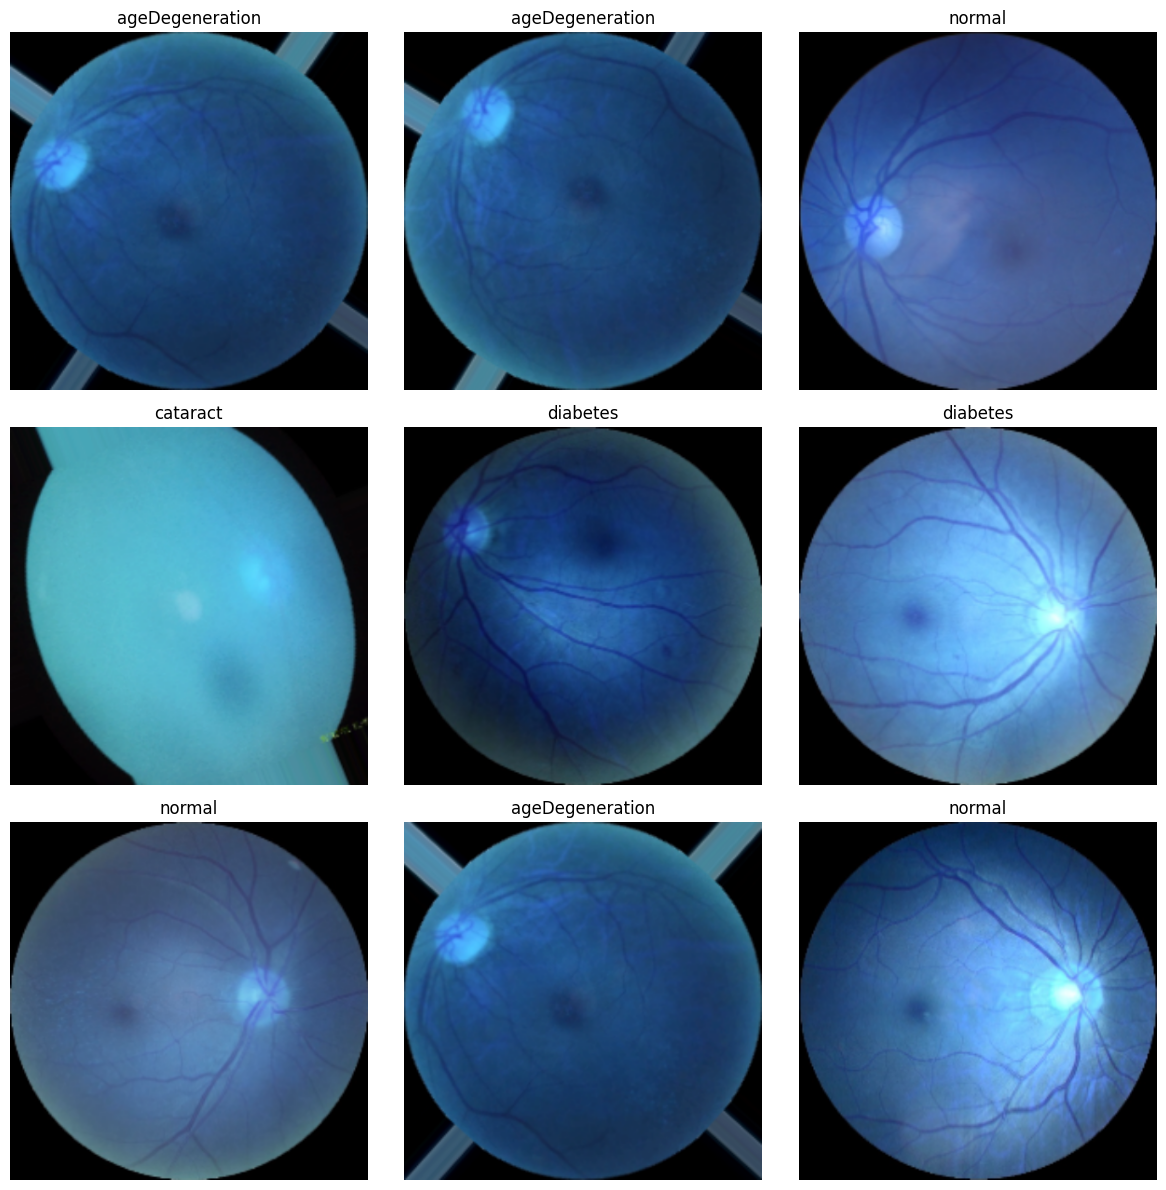

In [20]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[np.argmax(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

print("Dataset Pipeline Ready!")

Dataset Pipeline Ready!


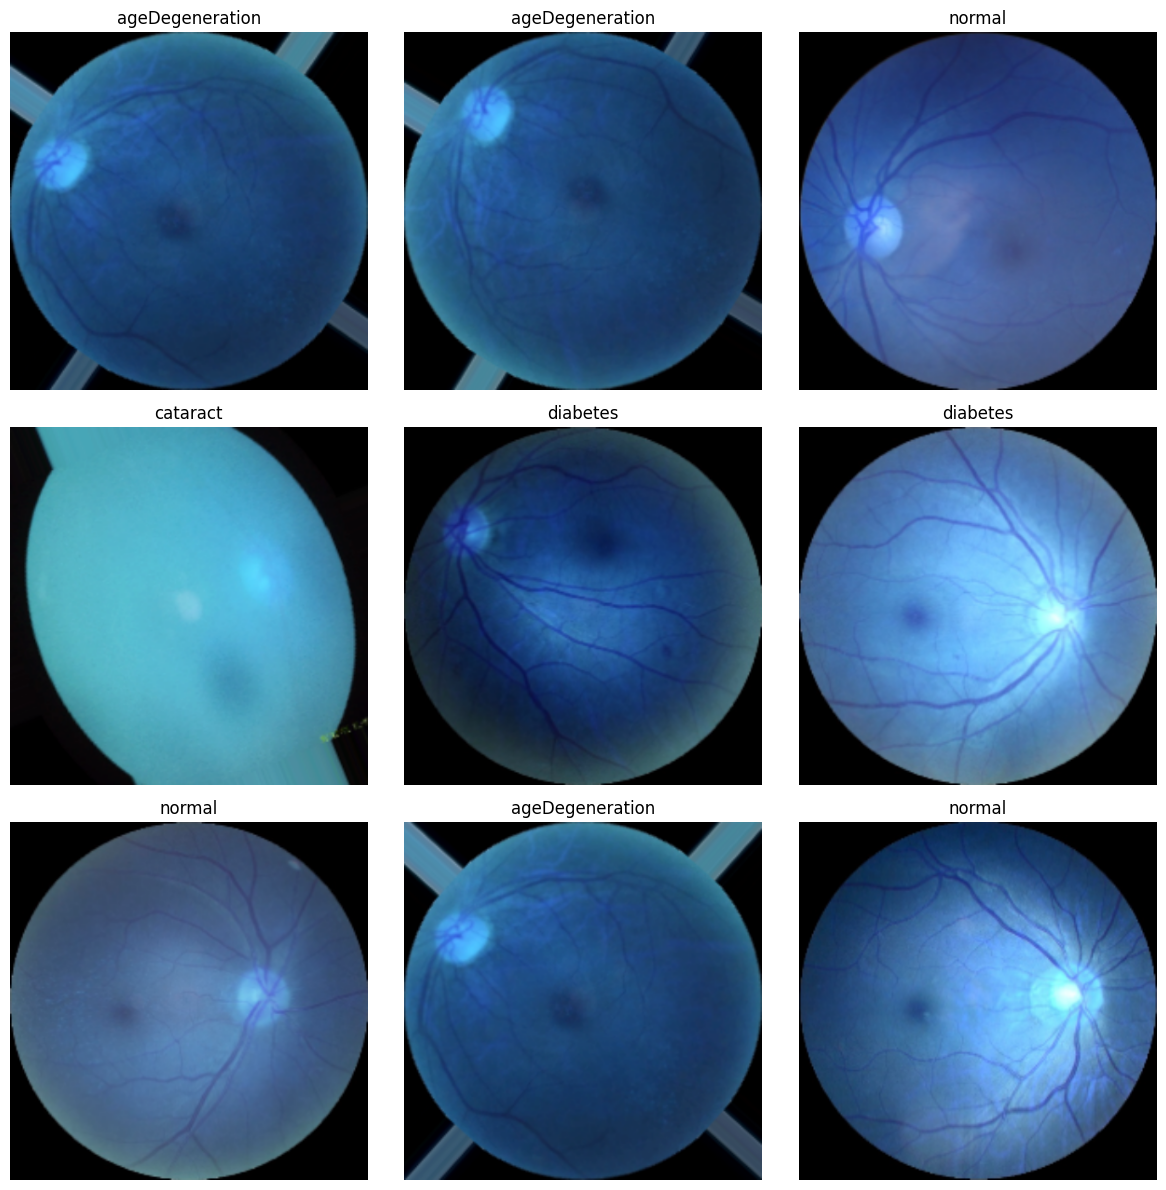

In [22]:
plt.figure(figsize=(12,12))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i].numpy().astype("uint8"))

    plt.title(class_names[np.argmax(labels[i])])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [23]:
from tensorflow import keras
from tensorflow.keras import layers
data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.08),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10),

], name="augmentation")

In [24]:
# ==========================================
# SECTION 5 : MODEL
# ==========================================

import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2S
base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(384,384,3)
)
# Freeze the backbone for Stage 1
base_model.trainable = False

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [25]:
inputs = tf.keras.Input(shape=(384, 384, 3))

# Data Augmentation
x = data_augmentation(inputs)

# EfficientNetV2 preprocessing
x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

# Feature extraction
x = base_model(x, training=False)

# Classification Head
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.4)(x)

x = layers.Dense(
    256,
    activation="relu"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32"
)(x)

model = Model(inputs, outputs)

In [26]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,667,239 (78.84 MB)

 Trainable params: 332,807 (1.27 MB)

 Non-trainable params: 20,334,432 (77.57 MB)

In [27]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=3e-4
)
model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [28]:
callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    )
]

In [29]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get labels from train_ds
y_train = []

for _, labels in train_ds.unbatch():
    y_train.append(np.argmax(labels.numpy()))

y_train = np.array(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: np.float64(1.195970695970696), 1: np.float64(1.1549659863945578), 2: np.float64(1.077968253968254), 3: np.float64(0.9624716553287982), 4: np.float64(1.1549659863945578), 5: np.float64(1.2387275645702611), 6: np.float64(0.6030404205441501)}


In [9]:
# Evaluate the model already in memory

test_loss, test_acc, test_precision, test_recall = model.evaluate(test_ds, verbose=1)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")

NameError: name 'model' is not defined

In [11]:
import os

found = False

for root, dirs, files in os.walk("/kaggle"):
    for file in files:
        if file.endswith(".keras"):
            print(os.path.join(root, file))
            found = True

if not found:
    print("No .keras model found.")

No .keras model found.


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

In [ ]:
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(
    gamma=2.0
)
optimizer = tf.keras.optimizers.Adam(
    learning_rate=3e-4   # Lower LR for fine-tuning
)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
base_model.trainable = True

# Freeze the lower layers, train only the top layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load best model
model = tf.keras.models.load_model("best_model.keras")

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save("baseline_84_8.keras")

In [ ]:
!pip install -q keras-tuner
import keras_tuner as kt
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras import layers
import tensorflow as tf

In [ ]:
def build_model(hp):

    base_model = EfficientNetV2S(
        include_top=False,
        weights="imagenet",
        input_shape=(384,384,3)
    )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=(384,384,3))

    x = data_augmentation(inputs)

    x = tf.keras.applications.efficientnet_v2.preprocess_input(x)

    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.BatchNormalization()(x)

    dropout = hp.Float(
        "dropout",
        min_value=0.2,
        max_value=0.5,
        step=0.1
    )

    x = layers.Dropout(dropout)(x)

    units = hp.Choice(
        "dense_units",
        values=[128,256,512]
    )

    x = layers.Dense(
        units,
        activation="relu"
    )(x)

    x = layers.BatchNormalization()(x)

    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(
        7,
        activation="softmax"
    )(x)

    model = tf.keras.Model(inputs, outputs)
    optimizer = tf.keras.optimizers.Adam(
    learning_rate=3e-4
)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=8,
    directory="tuner_results",
    project_name="ODIR10K"
)

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

base_model = model.get_layer("efficientnetv2-s")
last_conv_layer = "top_conv"

# Build a model from the EfficientNet input
grad_model = tf.keras.models.Model(
    inputs=base_model.input,
    outputs=[
        base_model.get_layer(last_conv_layer).output,
        base_model.output
    ]
)

In [ ]:
# Get one batch from the test dataset
images, labels = next(iter(test_ds))

# Select the first image
img_array = images[0].numpy()

# True label
true_label = np.argmax(labels[0].numpy())

print("True Label:", class_names[true_label])

plt.figure(figsize=(5,5))
plt.imshow(img_array.astype("uint8"))
plt.axis("off")
plt.show()

In [ ]:
base_model = model.get_layer("efficientnetv2-s")

for layer in reversed(base_model.layers):
    if "conv" in layer.name.lower():
        print(layer.name, layer.output.shape)
        break

In [ ]:
img = tf.expand_dims(img_array, axis=0)

# Pass through augmentation if your model has it
augmented = model.get_layer("augmentation")(img, training=False)

with tf.GradientTape() as tape:

    conv_outputs, features = grad_model(augmented)

    x = model.get_layer("global_average_pooling2d")(features)
    x = model.get_layer("batch_normalization")(x, training=False)
    x = model.get_layer("dropout")(x, training=False)
    x = model.get_layer("dense")(x)
    x = model.get_layer("batch_normalization_1")(x, training=False)
    x = model.get_layer("dropout_1")(x, training=False)

    preds = model.get_layer("dense_1")(x)

    class_idx = tf.argmax(preds[0])
    loss = preds[:, class_idx]

grads = tape.gradient(loss, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

conv_outputs = conv_outputs[0]

heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

heatmap = tf.maximum(heatmap,0)
heatmap /= tf.reduce_max(heatmap)

heatmap = heatmap.numpy()

In [ ]:
!pip install -q tf-keras-vis
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
model = tf.keras.models.load_model("best_model.keras")
images, labels = next(iter(test_ds))

image = images[0].numpy()
true_class = np.argmax(labels[0])

plt.figure(figsize=(5,5))
plt.imshow(image.astype("uint8"))
plt.title("Original Image")
plt.axis("off")
plt.show()

print("True Class :", class_names[true_class])

In [ ]:
model = tf.keras.models.load_model("best_model.keras")

model.save("ODIR10K_Final.keras")

In [ ]:
import numpy as np

misclassified = []

for images, labels in test_ds:

    predictions = model.predict(images, verbose=0)

    pred_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    for i in range(len(images)):

        if pred_classes[i] != true_classes[i]:

            misclassified.append({

                "image": images[i].numpy(),

                "true": true_classes[i],

                "pred": pred_classes[i],

                "confidence": np.max(predictions[i])

            })

print("Total Misclassified Images:", len(misclassified))

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,16))

for i in range(min(16, len(misclassified))):

    plt.subplot(4,4,i+1)

    plt.imshow(
        misclassified[i]["image"].astype("uint8")
    )

    plt.title(
        f"True: {class_names[misclassified[i]['true']]}\n"
        f"Pred: {class_names[misclassified[i]['pred']]}\n"
        f"Conf: {misclassified[i]['confidence']:.2f}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Collect predictions
y_true = []
y_score = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_score.extend(predictions)

y_true = np.array(y_true)
y_score = np.array(y_score)

# Convert labels to one-hot
y_true_bin = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

plt.figure(figsize=(10,8))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support

accuracy = accuracy_score(y_true, np.argmax(y_score, axis=1))

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    np.argmax(y_score, axis=1),
    average="weighted"
)

print("="*40)
print("FINAL MODEL PERFORMANCE")
print("="*40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print("="*40)

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "True Label": [class_names[i] for i in y_true],
    "Predicted Label": [class_names[i] for i in np.argmax(y_score, axis=1)],
    "Confidence": np.max(y_score, axis=1)
})

results.to_csv("Predictions.csv", index=False)

results.head()

In [ ]:
model = tf.keras.models.load_model("best_model.keras")

loss, accuracy, precision, recall = model.evaluate(test_ds, verbose=0)

print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

print("="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

loss, accuracy, precision, recall = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Precision     : {precision*100:.2f}%")
print(f"Recall        : {recall*100:.2f}%")

print("\nClassification Report")

pred = model.predict(test_ds, verbose=0)

pred = np.argmax(pred, axis=1)

true = []

for _, labels in test_ds:
    true.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(
    true,
    pred,
    target_names=class_names
))

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights
)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

print("="*50)
print("FINAL MODEL EVALUATION")
print("="*50)

loss, accuracy, precision, recall = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Precision     : {precision*100:.2f}%")
print(f"Recall        : {recall*100:.2f}%")

print("\nClassification Report")

pred = model.predict(test_ds, verbose=0)

pred = np.argmax(pred, axis=1)

true = []

for _, labels in test_ds:
    true.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(
    true,
    pred,
    target_names=class_names
))

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("best_model.keras")
loss, accuracy, precision, recall = model.evaluate(test_ds, verbose=1)

print(f"Test Loss      : {loss:.4f}")
print(f"Test Accuracy  : {accuracy*100:.2f}%")
print(f"Precision      : {precision*100:.2f}%")
print(f"Recall         : {recall*100:.2f}%")
from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(test_ds, verbose=0)
y_pred = np.argmax(predictions, axis=1)

y_true = []

for _, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
def preprocess(image, label):

    image = tf.py_function(
        apply_clahe,
        [image],
        tf.float32
    )

    image.set_shape((384,384,3))

    return image, label

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=(384,384),
    batch_size=16,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(384,384),
    batch_size=16,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(384,384),
    batch_size=16,
    label_mode="categorical",
    shuffle=False
)

In [ ]:
images, labels = next(iter(train_ds))
print(images.shape)

In [ ]:
!pip install -q opencv-python
import cv2
import numpy as np
import tensorflow as tf

def apply_clahe(image):

    image = image.numpy()

    print("Shape:", image.shape)

    if image.dtype != np.uint8:
        image = (image * 255).clip(0,255).astype(np.uint8)

    print("After uint8:", image.shape)

    if image.ndim == 2:
        print("GRAY IMAGE")
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

    elif image.ndim == 3 and image.shape[-1] == 1:
        print("1 CHANNEL")
        image = np.repeat(image, 3, axis=-1)

    elif image.ndim == 3 and image.shape[-1] == 4:
        print("RGBA")
        image = cv2.cvtColor(image, cv2.COLOR_RGBA2RGB)

    print("Before LAB:", image.shape)

    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))

    image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    return image.astype(np.float32)/255.

In [ ]:
images, labels = next(iter(train_ds))

img = images[0]

result = apply_clahe(img)

print(result.shape)

In [ ]:
import os
import cv2
from tqdm import tqdm
INPUT_DATASET = "/kaggle/input/odir5k-splitted"

OUTPUT_DATASET = "/kaggle/working/ODIR_CLAHE"
def apply_clahe(image):

    lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    lab = cv2.merge((l,a,b))

    image = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    return image

In [ ]:
splits = ["train", "validation", "test"]

for split in splits:

    input_split = os.path.join(INPUT_DATASET, split)
    output_split = os.path.join(OUTPUT_DATASET, split)

    os.makedirs(output_split, exist_ok=True)

    classes = sorted(os.listdir(input_split))

    for cls in classes:

        input_class = os.path.join(input_split, cls)
        output_class = os.path.join(output_split, cls)

        os.makedirs(output_class, exist_ok=True)

        images = os.listdir(input_class)

        print(f"\nProcessing {split}/{cls}")

        for img_name in tqdm(images):

            img_path = os.path.join(input_class, img_name)

            image = cv2.imread(img_path)

            if image is None:
                continue

            image = apply_clahe(image)

            save_path = os.path.join(output_class, img_name)

            cv2.imwrite(save_path, image)